In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## this makes the ipython notebook take up most of the page 
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

from astropy.io import fits
import astropy.table as table
from astropy.io import ascii

from astropy import units as u
from collections import Counter
from astropy.time import Time
import astropy.coordinates as coord


# some reviews for reading

https://ui.adsabs.harvard.edu/abs/2008ConPh..49...71T/abstract

https://ui.adsabs.harvard.edu/abs/2010arXiv1008.4686H/abstract

https://emcee.readthedocs.io/en/stable/tutorials/line/

In [2]:
import emcee

import corner

In [3]:
plt.style.use('/Users/apace/.matplotlib/stylelib/std.mplstyle')##

In [4]:
## NGC 288 properties
ra0, dec0 = 13.1885, -26.582611 ## deg
distance = 8.9 # kpc
pmra_mean, pmdec_mean = 4.1641, -5.7053 ## mas / yr (Gaia units)
vlos= -44.45 ## km/s, there are only a few stars in the Gaia catalog with velocities
parallax_mean = 1./distance
rhalf = 2.23 ## arcmin
rmax =30. ## 30 arcmin

In [9]:
## change file path
# fp = "/Users/apace/Downloads/ngc_288.fits"
# gaia_dr3 = table.Table(fits.open(fp)[1].data)
gaia_dr3 = table.Table(np.load('/Users/apace/Downloads/ngc_0288.npy', allow_pickle=True))

In [10]:
def coord_change(ra, dec, r,d, dist=180./np.pi*60., rotate=90, q=1.):
    ra = np.array(ra)
    dec = np.array(dec)
    a = np.pi/180.
    x =  dist*np.cos(a * dec)* np.sin(a*(ra - r))
    y = dist*(np.sin(a*dec) *np.cos(a*d) - np.cos(a*dec)*np.sin(a*d) * np.cos(a*(ra - r)))
    angle = (90.-rotate)*np.pi/180.
    xr = x*np.cos(angle) + y*np.sin(angle)
    yr = -x*np.sin(angle) + y*np.cos(angle)

    return x,y, np.sqrt(x**2 + y**2), xr, yr, np.sqrt(xr**2 + yr**2/q**2)

In [11]:
def prob_plummer(r, rh, rmax):
    return 2.*r*rh**2 * (rh**2 + rmax**2)/rmax**2 /(r**2 + rh**2)**2
def prob_mw(r, rmax):
    return 2.*r/rmax**2

In [12]:
## radius from center of the clusters 
temp = coord_change(gaia_dr3['ra'], gaia_dr3['dec'], ra0, dec0)
gaia_dr3['rad'] = temp[2]

In [13]:
## spatial probability
## instead of varying or fitting this, I am fixing to literature values 
##. rhalf is from literature
## rmax is the size of our data
gaia_dr3['prob_plummer'] = prob_plummer(gaia_dr3['rad'], rhalf, rmax)
gaia_dr3['prob_mw'] = prob_mw(gaia_dr3['rad'], rmax)

Text(0.5, 0, 'radius (arcmin)')

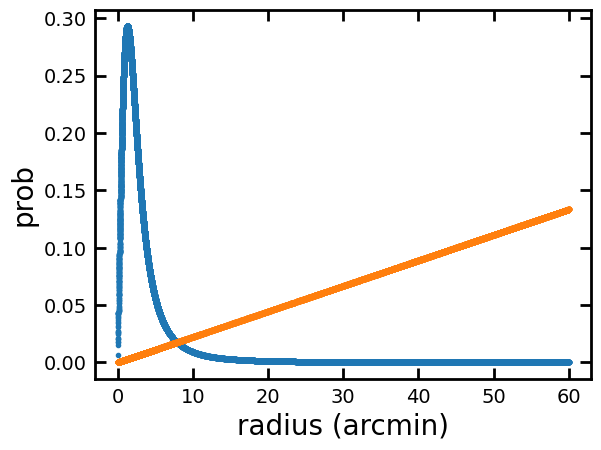

In [14]:
## spatial probability to be associated with GC or MW
plt.plot(gaia_dr3['rad'],gaia_dr3['prob_plummer'], '.')
plt.plot(gaia_dr3['rad'],gaia_dr3['prob_mw'], '.')
plt.ylabel('prob')
plt.xlabel('radius (arcmin)')

In [29]:
gaia_dr3_good = gaia_dr3[np.logical_and.reduce((gaia_dr3['ruwe']<1.4, gaia_dr3['astrometric_excess_noise_sig']<2, gaia_dr3['phot_g_mean_mag']<20))]
## adding G band cut here
len(gaia_dr3_good)

10410

In [16]:
## 4 cuts here,
## 3 sigma cuts in pmra, pmdec, parallax (sigma clipping around known values)
## can add dispersion term in here too (will need for later )
pm_sigma = 0.15
pmra_error = 0.0243
pmdec_error = 0.0241
parallax_mean_error = 0.0002

select_candidate_dispersion = gaia_dr3[np.logical_and.reduce((
    abs(gaia_dr3['pmra']-pmra_mean) < 3.*np.sqrt(gaia_dr3['pmra_error']**2 + pm_sigma**2 + pmra_error**2), 
    abs(gaia_dr3['pmdec']-pmdec_mean) < 3.*np.sqrt(gaia_dr3['pmdec_error']**2 + pm_sigma**2 + pmdec_error**2),
    abs(gaia_dr3['parallax']-parallax_mean) < 3.*np.sqrt(gaia_dr3['parallax_error']**2 + parallax_mean_error**2), gaia_dr3['phot_g_mean_mag']<20))]
## this also cuts out fainter stars (with larger errors)
len(select_candidate_dispersion)

6459

(-15.0, 10.0)

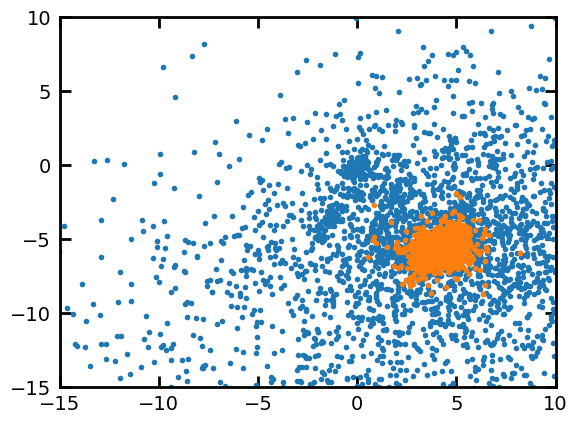

In [19]:
plt.plot(gaia_dr3_good['pmra'], gaia_dr3_good['pmdec'],'.')
plt.plot(select_candidate_dispersion['pmra'], select_candidate_dispersion['pmdec'],'.')
plt.xlim(-15, 10)
plt.ylim(-15, 10)

In [20]:
gaia_dr3_good_small = gaia_dr3_good[np.sqrt(gaia_dr3_good['pmra']**2 + gaia_dr3_good['pmdec']**2)<50]

6506

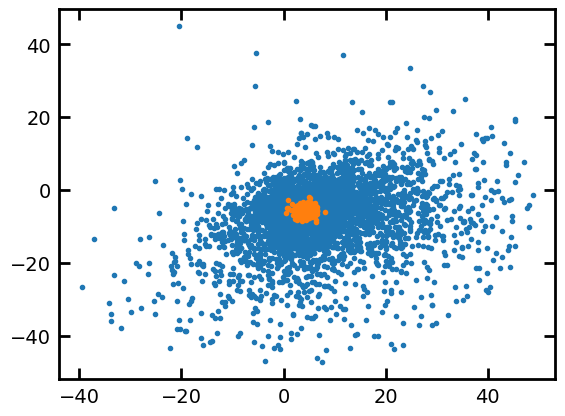

In [21]:
plt.plot(gaia_dr3_good_small['pmra'], gaia_dr3_good_small['pmdec'],'.')
plt.plot(select_candidate_dispersion['pmra'], select_candidate_dispersion['pmdec'],'.')


In [22]:
## this is mcmc to compute mean motion (pmra, pmdec) and proper motion dispersion (sigma_pmra, sigma_pmdec)
def lnprob_pm_sigma(theta, data, limits, member):
    lp = lnprior_pm_sigma(theta, data, limits)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_pm_sigma(theta, data, member)

def lnlike_pm_sigma(theta, data, member):
    mean_pmra, mean_pmdec, sigma_pmra, sigma_pmdec = theta
    sigma_pmra=10**sigma_pmra
    sigma_pmdec = 10**sigma_pmdec
    vx = mean_pmra - data[0]
    vy = mean_pmdec - data[1]
    sxx = data[2]**2 + sigma_pmra**2
    syy =  data[3]**2 + sigma_pmdec**2
    sxy = data[4] * data[2] * data[3]

    term = -np.sum(member*((syy*vx*vx + sxx*vy*vy - 2. *sxy *vx*vy)/(sxx*syy - sxy*sxy))/2. + np.log(4.*np.pi*np.pi * (sxx*syy - sxy*sxy))/2.)

    return term

def lnprior_pm_sigma(theta, data, limits):
    v, s,pmra,pmdec = theta
    #     limits = [16, 20, 0, 2]
    if limits[0] < v < limits[1] and limits[2] < s < limits[3] and limits[4] < pmra < limits[5] and limits[6] < pmdec < limits[7]:
        return 0.0
    return -np.inf


def mcmc_pm_sigma(data,  **kwargs):
    ndim = 4

    nwalkers = kwargs.get('nwalkers',20) # number of MCMC walkers
    nburn    = kwargs.get('nburn',500)    # "burn-in" period to let chains stabilize
    nsteps   = kwargs.get('nsteps',5000) # number of MCMC steps to take
    nthreads = kwargs.get('nthreads',1)  # number of threads
    limits = kwargs.get('limits', [data[0].min(), data[0].max(), data[1].min(), data[1].max(), -2,  1, -2, 1])
    member = kwargs.get('member', np.array([1.]*len(data[0])))
    # sigma_pm = kwargs.get('sigma_pm', 0.)

    mu = np.random.random(nwalkers) * (limits[1] - limits[0])  + limits[0] # uniform dist. from vmin to vmax
    #sigma = np.random.random(nwalkers) *  2. # uniform dist. from 10^-2 to 10^2 km/s (A Jeffery's prior)
    sigma = np.random.random(nwalkers) * (limits[3] - limits[2])  + limits[2]
    sig_pmra = np.random.random(nwalkers) * (limits[5] - limits[4])  + limits[4]
    sig_pmdec = np.random.random(nwalkers) * (limits[7] - limits[6])  + limits[6]

    starting_guesses = np.vstack([mu, sigma, sig_pmra, sig_pmdec]).T
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob_pm_sigma,
                                    args=[data, limits, member], threads=nthreads)
    pos,prob,state = sampler.run_mcmc(starting_guesses,nburn+nsteps,progress=True)

    return sampler

In [ ]:
## this is to calculate the dispersion from the sample we selected with 3 sigma cuts

In [24]:
data2= [select_candidate_dispersion['pmra'], 
        select_candidate_dispersion['pmdec'], 
       select_candidate_dispersion['pmra_error'], 
       select_candidate_dispersion['pmdec_error'],
       select_candidate_dispersion['pmra_pmdec_corr'],]
# limits = [-3.2, -2.2, -5, 5, -2,  1, -2, 1]
samp = mcmc_pm_sigma(data2, nsteps=15000, limits = [2, 6, -8, -4, -2,  1, -2, 1])
flat_samples = samp.get_chain(discard=5000, thin=20, flat=True)


You must install the tqdm library to use progress indicators with emcee


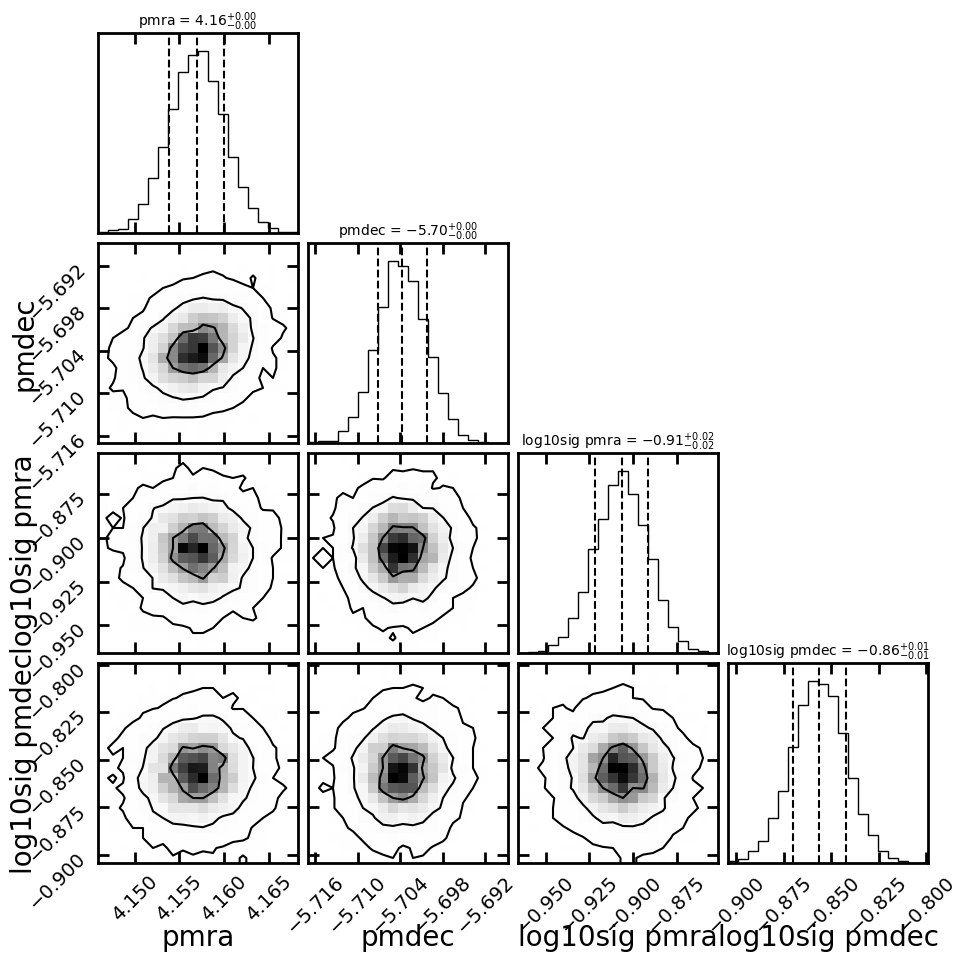

4.15696957980537 0.003147507240658598 0.003077081617629318 0.003112294429143958
-5.703830482522736 0.003406441458535525 0.0036074857799102134 0.0035069636192228693


In [26]:
ndim = 4

corn = corner.corner(flat_samples,quantiles=[0.16, 0.50, 0.84], 
                           show_titles=True, title_kwargs={"fontsize": 10},
                           plot_datapoints = False,bins=[20]*len(flat_samples.T),levels=[ 0.393469, 0.864665, 0.988891],
                           labels=['pmra','pmdec', 'log10sig pmra', 'log10sig pmdec'])
plt.show()

mean = corner.quantile(flat_samples.T[0], [.5, .1587, .8413, 0.0227501, 0.97725], )
print(mean[0], mean[0]-mean[1], mean[2]-mean[0], (mean[2]-mean[1])/2.)
mean = corner.quantile(flat_samples.T[1], [.5, .1587, .8413, 0.0227501, 0.97725], )
print(mean[0], mean[0]-mean[1], mean[2]-mean[0], (mean[2]-mean[1])/2.)

In [16]:
## one item to note, all the dispersion terms here are in log10 units (Jefferys prior, ie scale free prior)

In [ ]:
## mixture model example 

In [27]:
def lnprob_pm_sigma_mix(theta, data, limits, member):
    lp = lnprior_pm_sigma_mix(theta, data, limits)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_pm_sigma_mix(theta, data, member)

def lnlike_pm_sigma_mix(theta, data, member):
    ## note that sigma MW and sigma GC are different
    mean_pmra, mean_pmdec, sigma_pmra, sigma_pmdec, mean_pmra_mw, mean_pmdec_mw, sigma_pmra_mw, sigma_pmdec_mw, frac = theta
    sigma_pmra=10**sigma_pmra
    sigma_pmdec = 10**sigma_pmdec
    vx = mean_pmra - data[0]
    vy = mean_pmdec - data[1]
    sxx = data[2]**2 + sigma_pmra**2
    syy =  data[3]**2 + sigma_pmdec**2
    sxy = data[4] * data[2] * data[3]

    sigma_pmra_mw = 10**sigma_pmra_mw
    sigma_pmdec_mw = 10**sigma_pmdec_mw
    
    vx_mw = mean_pmra_mw - data[0]
    vy_mw = mean_pmdec_mw - data[1]
    sxx_mw = data[2]**2 + sigma_pmra_mw**2
    syy_mw =  data[3]**2 + sigma_pmdec_mw**2
    sxy_mw = data[4] * data[2] * data[3]
    
    ## spatial
    prob_plummer = data[5]
    prob_mw = data[6]

    term = np.sum( np.log(frac *prob_plummer* np.exp(-(syy*vx*vx + sxx*vy*vy - 2. *sxy *vx*vy)/(sxx*syy - sxy*sxy)/2.) /np.sqrt(4.*np.pi*np.pi * (sxx*syy - sxy*sxy)) +  (1.-frac) *prob_mw* np.exp(-(syy_mw*vx_mw*vx_mw + sxx_mw*vy_mw*vy_mw - 2. *sxy_mw *vx_mw*vy_mw)/(sxx_mw*syy_mw - sxy_mw*sxy_mw)/2.) /np.sqrt(4.*np.pi*np.pi * (sxx_mw*syy_mw - sxy_mw*sxy_mw))) )

    return term

def lnprior_pm_sigma_mix(theta, data, limits):
    mean_pmra, mean_pmdec, sigma_pmra, sigma_pmdec, mean_pmra_mw, mean_pmdec_mw, sigma_pmra_mw, sigma_pmdec_mw, frac = theta
    
    for i in range(int(len(limits)/2)):
        if np.logical_or(theta[i] < limits[2*i], theta[i] > limits[2*i+1]):
            return -np.inf
    if np.logical_or(sigma_pmra > sigma_pmra_mw ,sigma_pmdec > sigma_pmdec_mw ):
        return -np.inf
    
    return 0.


def mcmc_pm_sigma_mix(data,  **kwargs):
    ndim = 4+5

    nwalkers = kwargs.get('nwalkers',20) # number of MCMC walkers
    nburn    = kwargs.get('nburn',500)    # "burn-in" period to let chains stabilize
    nsteps   = kwargs.get('nsteps',5000) # number of MCMC steps to take
    nthreads = kwargs.get('nthreads',1)  # number of threads
    limits = kwargs.get('limits', [data[0].min(), data[0].max(), data[1].min(), data[1].max(), -2,  1, -2, 1, data[0].min(), data[0].max(), data[1].min(), data[1].max(), -2,  1, -2, 1, 0,1])
    member = kwargs.get('member', np.array([1.]*len(data[0])))
    mean_pmra = kwargs.get('mean_pmra', False)
    mean_pmdec = kwargs.get('mean_pmdec', False)
    sigma_pmra_mean = kwargs.get('sigma_pmra_mean', False)
    sigma_pmdec_mean = kwargs.get('sigma_pmdec_mean', False)
    # sigma_pm = kwargs.get('sigma_pm', 0.)
    
    
    
    start_pmra = np.random.random(nwalkers) * (limits[1] - limits[0])  + limits[0] # uniform dist. from vmin to vmax
    start_pmdec = np.random.random(nwalkers) * (limits[3] - limits[2])  + limits[2]
    
    if mean_pmra:
        start_pmra = np.random.normal(mean_pmra, .01, nwalkers)
    if mean_pmdec:
        start_pmdec = np.random.normal(mean_pmdec, .01, nwalkers)
        
    start_sig_pmra_mw = np.random.random(nwalkers) * (limits[5+8] - limits[4+8])  + limits[4+8]
    start_sig_pmdec_mw = np.random.random(nwalkers) * (limits[7+8] - limits[6+8])  + limits[6+8]    
    
    start_sig_pmra = np.random.random(nwalkers) * (start_sig_pmra_mw - limits[4])  + limits[4] ## this should make 
    start_sig_pmdec = np.random.random(nwalkers) * (start_sig_pmdec_mw - limits[6])  + limits[6]
    
    if sigma_pmra_mean:
        start_sig_pmra = np.random.normal(sigma_pmra_mean, .01, nwalkers)
    if sigma_pmdec_mean:
        start_sig_pmdec = np.random.normal(sigma_pmdec_mean, .01, nwalkers)
    
    start_pmra_mw = np.random.random(nwalkers) * (limits[1+8] - limits[0+8])  + limits[0+8]
    start_pmdec_mw = np.random.random(nwalkers) * (limits[3+8] - limits[2+8])  + limits[2+8]
    
    frac = np.random.random(nwalkers) 
    
    
    
    starting_guesses = np.vstack([start_pmra, start_pmdec, start_sig_pmra, start_sig_pmdec, start_pmra_mw, start_pmdec_mw, start_sig_pmra_mw, start_sig_pmdec_mw, frac]).T
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob_pm_sigma_mix,
                                    args=[data, limits, member], threads=nthreads)
    pos,prob,state = sampler.run_mcmc(starting_guesses,nburn+nsteps,progress=True)

    return sampler

In [30]:
## data cleaning
## this removes high proper motion stars, faint sources, and nearby sources
## 
gaia_dr3_good_small_parallax = gaia_dr3_good[np.logical_and.reduce((np.sqrt(gaia_dr3_good['pmra']**2 + gaia_dr3_good['pmdec']**2)<20, gaia_dr3_good['parallax']<1, gaia_dr3_good['phot_g_mean_mag']<20, gaia_dr3_good['rad']<30))]
len(gaia_dr3_good_small_parallax)

6453

In [106]:
## proper motion dispersion of ~ 10 km/s in log 10 units 
np.log10(10/4.74/9)

-0.6300208511134099

In [31]:
data2_small= [gaia_dr3_good_small_parallax['pmra'], 
        gaia_dr3_good_small_parallax['pmdec'], 
       gaia_dr3_good_small_parallax['pmra_error'], 
       gaia_dr3_good_small_parallax['pmdec_error'],
       gaia_dr3_good_small_parallax['pmra_pmdec_corr'],
             gaia_dr3_good_small_parallax['prob_plummer'],
             gaia_dr3_good_small_parallax['prob_mw'],]
# limits = [-3.2, -2.2, -5, 5, -2,  1, -2, 1]
limits = [2, 6, -8, -4, -2,  -0.7, -2, -0.7, -10,10,-10,10, -0.5,  10, -0.5, 10, 0,1]
print(len(limits))
samp = mcmc_pm_sigma_mix(data2_small, nsteps=25000, mean_pmra=pmra_mean, mean_pmdec=pmdec_mean, nwalkers=30, sigma_pmra_mean=np.log10(.15), sigma_pmdec_mean=np.log10(.15), limits=limits)

/var/folders/xw/lxf9f3tx4z519xl72nm3_nn00000gn/T/ipykernel_96731/2455553365.py:28: RuntimeWarning: divide by zero encountered in log
  term = np.sum( np.log(frac *prob_plummer* np.exp(-(syy*vx*vx + sxx*vy*vy - 2. *sxy *vx*vy)/(sxx*syy - sxy*sxy)/2.) /np.sqrt(4.*np.pi*np.pi * (sxx*syy - sxy*sxy)) +  (1.-frac) *prob_mw* np.exp(-(syy_mw*vx_mw*vx_mw + sxx_mw*vy_mw*vy_mw - 2. *sxy_mw *vx_mw*vy_mw)/(sxx_mw*syy_mw - sxy_mw*sxy_mw)/2.) /np.sqrt(4.*np.pi*np.pi * (sxx_mw*syy_mw - sxy_mw*sxy_mw))) )
You must install the tqdm library to use progress indicators with emcee


18


/Users/apace/miniconda3/envs/fix_env/lib/python3.14/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [35]:
flat_samples = samp.get_chain(discard=15000, thin=30, flat=True)

In [ ]:
# posterior sample

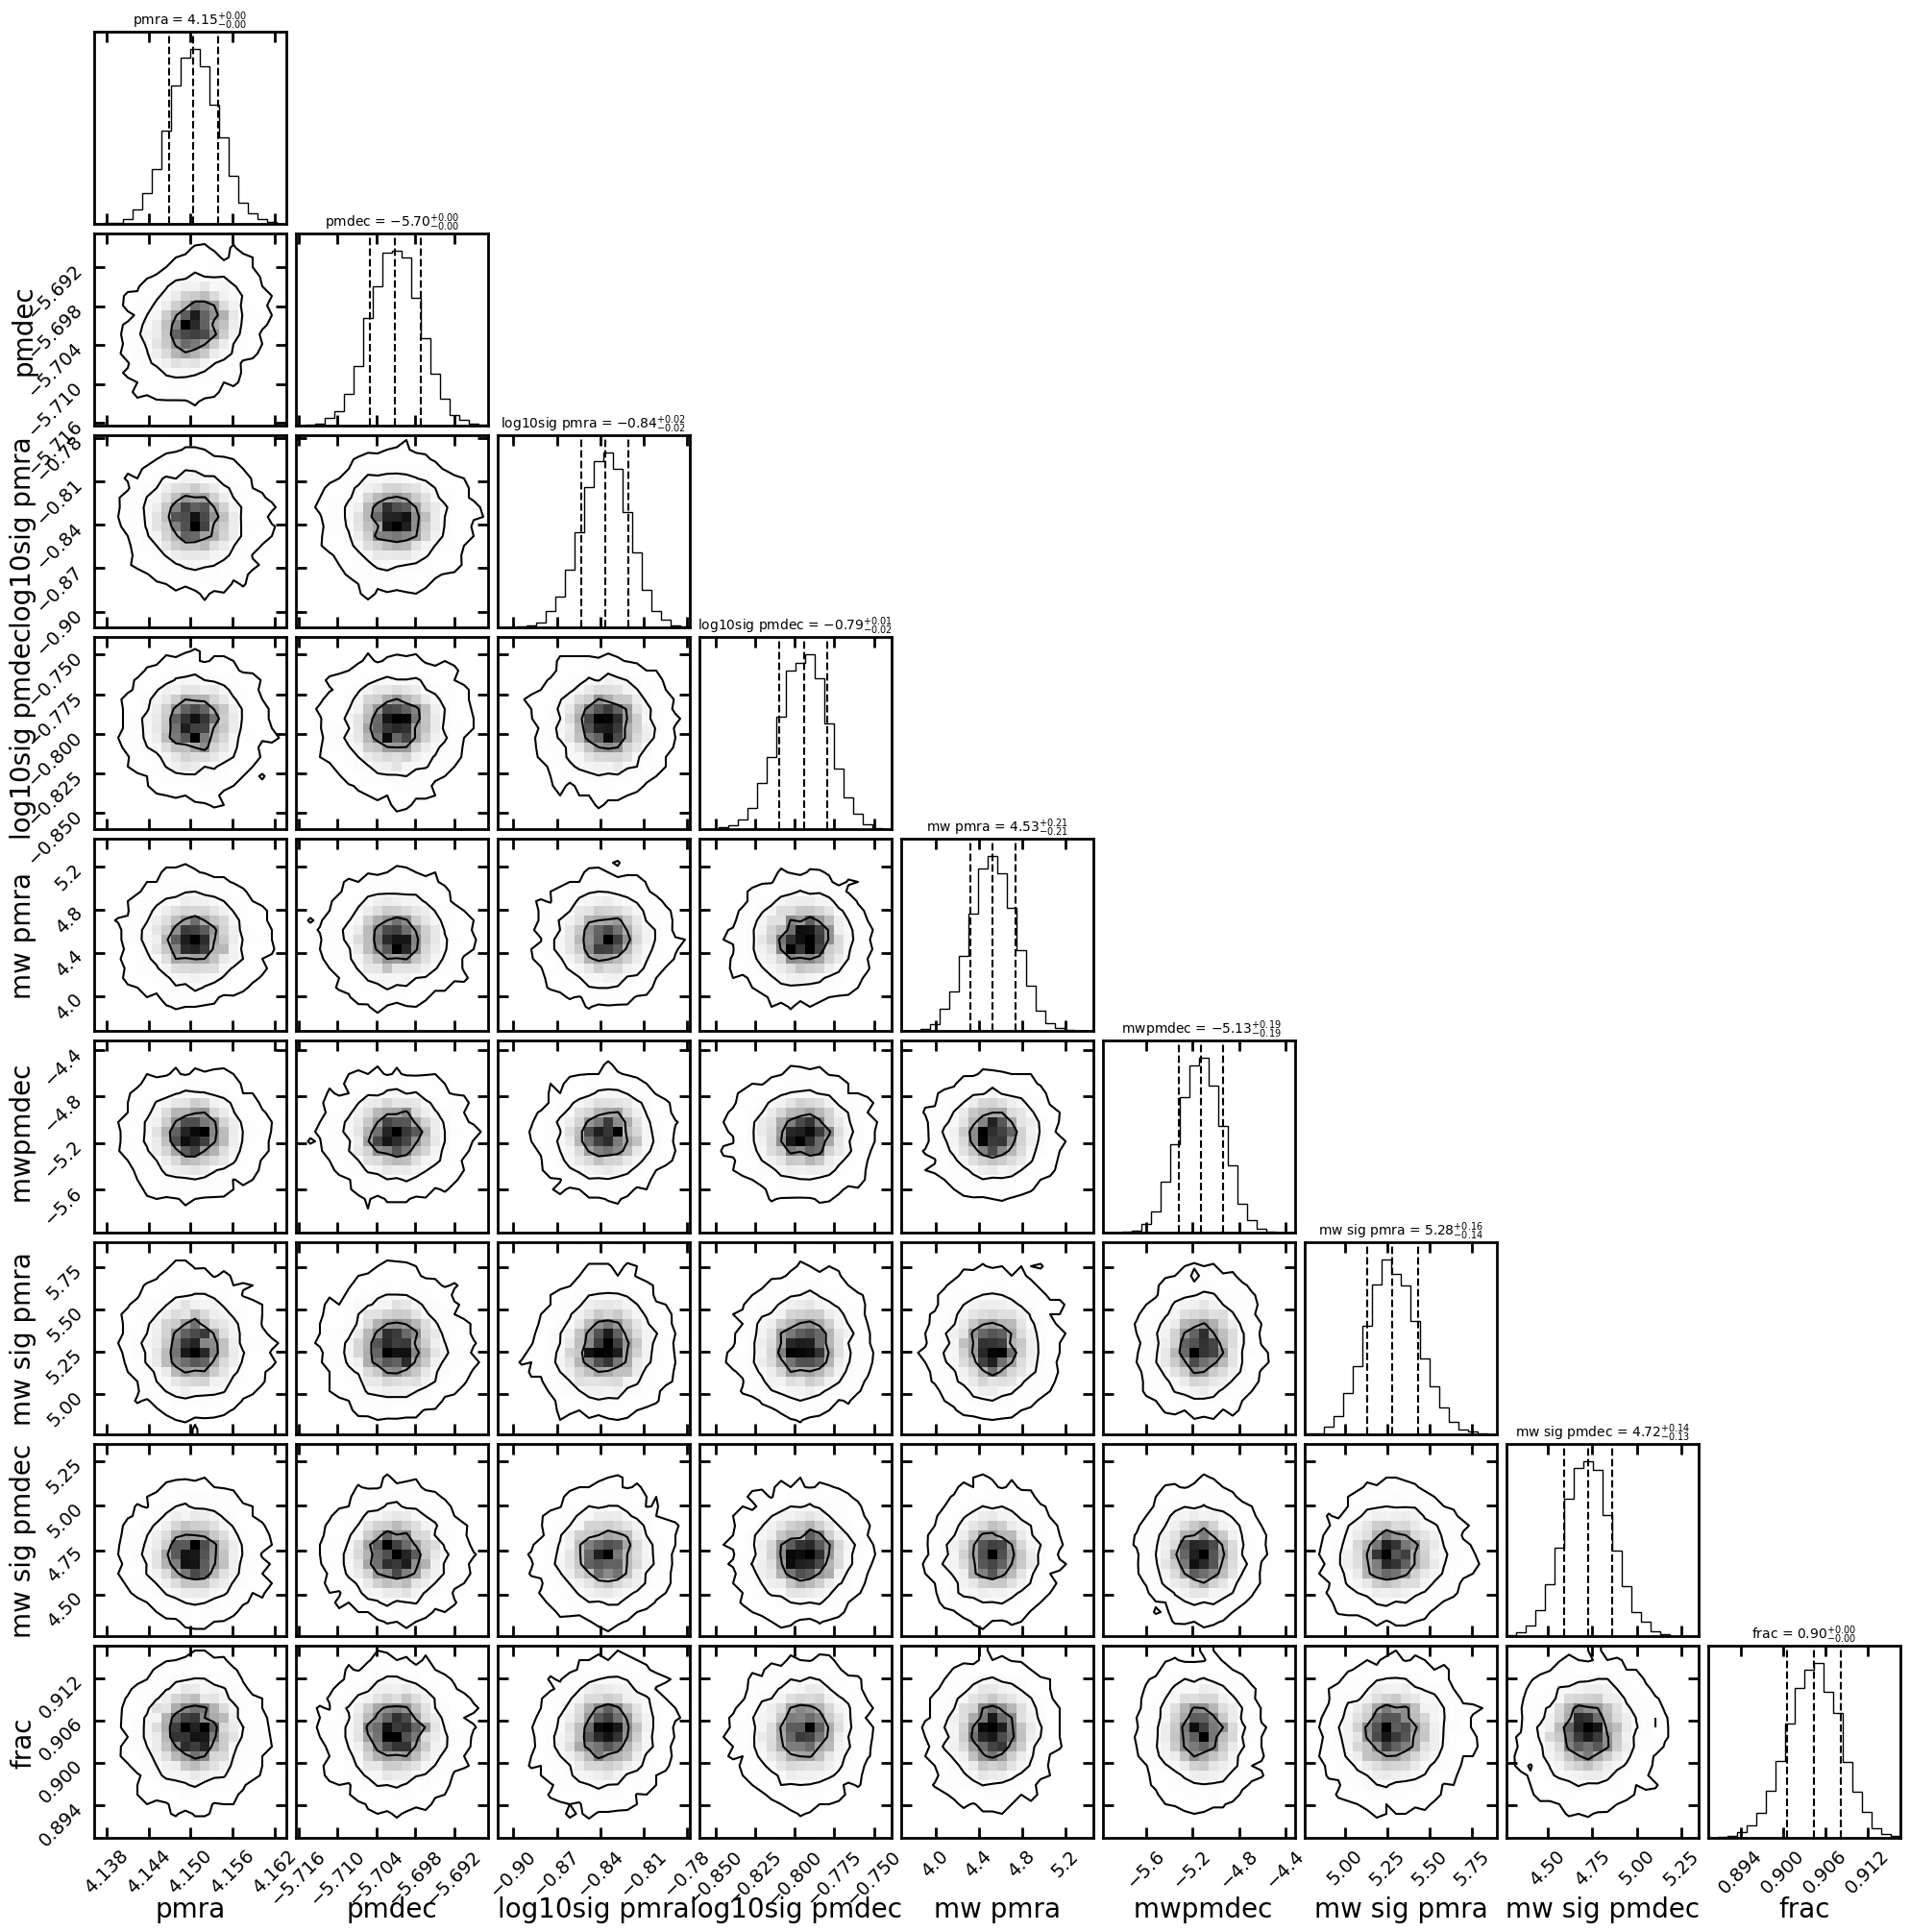

4.150424758275805 0.0035040375685371217 0.0035610331858864086 0.003532535377211765
-5.701087487446728 0.0038891608509912245 0.0038914244272483245 0.0038902926391197745


In [36]:
ndim = 9

corn = corner.corner(flat_samples,quantiles=[0.16, 0.50, 0.84], 
                           show_titles=True, title_kwargs={"fontsize": 10},
                           plot_datapoints = False,bins=[20]*len(flat_samples.T),levels=[ 0.393469, 0.864665, 0.988891],
                           labels=['pmra','pmdec', 'log10sig pmra', 'log10sig pmdec', 'mw pmra',' mwpmdec', 'mw sig pmra', 'mw sig pmdec', 'frac'])
plt.show()

mean = corner.quantile(flat_samples.T[0], [.5, .1587, .8413, 0.0227501, 0.97725], )
print(mean[0], mean[0]-mean[1], mean[2]-mean[0], (mean[2]-mean[1])/2.)
mean = corner.quantile(flat_samples.T[1], [.5, .1587, .8413, 0.0227501, 0.97725], )
print(mean[0], mean[0]-mean[1], mean[2]-mean[0], (mean[2]-mean[1])/2.)

In [ ]:
## best fit model from the posterior (its not that great)

In [34]:
tau = samp.get_autocorr_time(discard=15000, thin=30)
print(tau)
## for coverage 

[113.47774849 108.82179678 105.53090154 107.97559717 121.44386956
 113.3341884  102.87174848 102.65338625 104.90945775]


In [39]:
# simple membership
gaia_dr3_good_small_parallax['membership_simple'] = np.zeros(len(gaia_dr3_good_small_parallax), dtype=float)
f = 0.9
for i in range(len(gaia_dr3_good_small_parallax)):
    sat = stats.norm.pdf(gaia_dr3_good_small_parallax['pmra'][i], 4.15, np.sqrt((10**-0.84) **2  + gaia_dr3_good_small_parallax['pmdec_error'][i]**2))  * stats.norm.pdf(gaia_dr3_good_small_parallax['pmdec'][i], -5.7, np.sqrt((10**-0.79) **2  + gaia_dr3_good_small_parallax['pmdec_error'][i]**2))
    mw = stats.norm.pdf(gaia_dr3_good_small_parallax['pmra'][i], 4.54, np.sqrt((5.28) **2  + gaia_dr3_good_small_parallax['pmdec_error'][i]**2))  * stats.norm.pdf(gaia_dr3_good_small_parallax['pmdec'][i], -5.13, np.sqrt((4.72) **2  + gaia_dr3_good_small_parallax['pmdec_error'][i]**2))
    
    gaia_dr3_good_small_parallax['membership_simple'][i] = f * gaia_dr3_good_small_parallax['prob_plummer'][i] * sat /(f * gaia_dr3_good_small_parallax['prob_plummer'][i] * sat + (1.-f) * gaia_dr3_good_small_parallax['prob_mw'][i] * mw)

In [40]:
high_prob = gaia_dr3_good_small_parallax[gaia_dr3_good_small_parallax['membership_simple']>0.9]

In [38]:
import scipy.stats as stats

In [41]:
x = np.arange(-10, 10, .01)
pmra_tot = []
pmdec_tot = []
for i in x:
    f = 0.9
    pmra_temp = f * stats.norm.pdf(i, 4.15, 10**-0.84) + (1.-f) * stats.norm.pdf(i, 4.54, 5.28) 
    pmra_tot.append([pmra_temp, stats.norm.pdf(i, 4.54, 5.28) ])
    
    pmdec_temp = f * stats.norm.pdf(i, -5.7, 10**-0.79) + (1.-f) * stats.norm.pdf(i, -5.13, 4.72) 
    pmdec_tot.append([pmdec_temp, stats.norm.pdf(i, -5.13, 4.72) ])
pmra_tot = np.array(pmra_tot)
pmdec_tot = np.array(pmdec_tot)

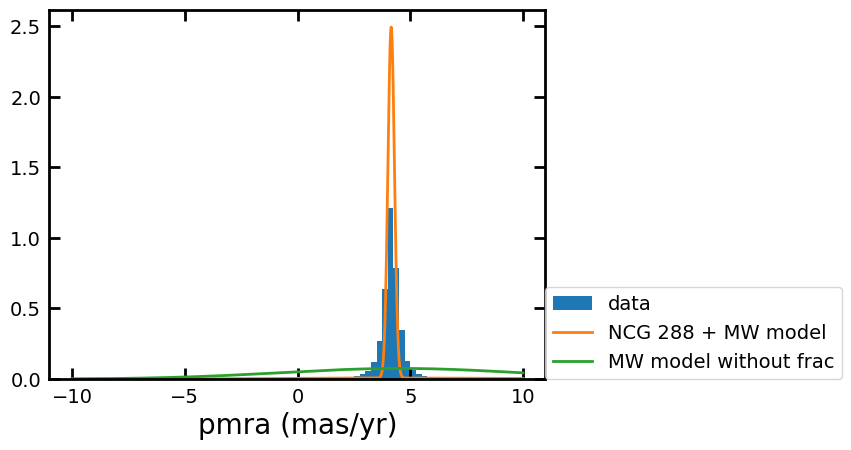

In [47]:
t = plt.hist(gaia_dr3_good_small_parallax['pmra'],bins=np.arange(-10,10,.25), density=True, label='data')
t = plt.plot(x, pmra_tot.T[0], label='NCG 288 + MW model', lw=2)
t = plt.plot(x, pmra_tot.T[1], label='MW model without frac', lw=2)
plt.legend(loc=(1,0))
# x = plt.hist(select_candidate_dispersion['pmra'], bins=100)
plt.xlabel('pmra (mas/yr)')
plt.show()

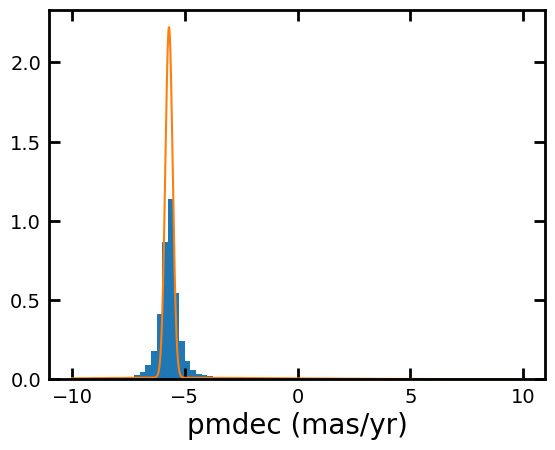

In [43]:
t = plt.hist(gaia_dr3_good_small_parallax['pmdec'], bins=np.arange(-10,10,.25), density=True)
t = plt.plot(x, pmdec_tot.T[0])
# x = plt.hist(select_candidate_dispersion['pmra'], bins=100)
plt.xlabel('pmdec (mas/yr)')
plt.show()

In [ ]:
 # https://scikit-learn.org/stable/modules/mixture.html